# **1. 스타버스 주변 소상공인 / 커피 프랜차이즈 입점 전략 분석**

### 1. 분석 목표
- 1. 스타벅스 주변에 커피 전문점이 많이 분포하는가?
- 2. 특정 프랜차이즈는 스타벅스와 가까운 곳에 입점하는 경행이 있는가?
- 3. 어느 자치구에서 스타벅스와 프랜차이즈가 함께 밀집되어 있는가?
- 4. 거리 구간별, 브랜드별, 자치구별, 시각화를 통해 어떤 결론을 낼 수 있는가?

### 2. 분석 주의점
- 이 분석은 위치 데이터 기반의 상관관계 분석임
    - 상관관계: 두 현상이 함께 변하는 관계를 말함. 같이 변한다고 해서 원인과 결과는 아님. 예) 아이스크림 판매량이 증가할수록 익사 사고도 많이 증가한다.
    - 인과관계: 한 현상이 다른 현상의 원인이 되는 관계를 말함. 예) 비가 많이 오면 우산 판매량이 증가한다.
- 소상공인 데이터에 개업일 또는 입ㅈ점 순서가 없어서 "스타벅스가 먼저 생기고 주변에 다른 가게가 생겼다"는 인과관계도 증명할 수 없음



In [154]:
from pathlib import Path
import pandas as pd

In [155]:
BASE_DIR = Path.cwd()
print("현재 작업 폴더:  ", BASE_DIR)
DATA_DIR = BASE_DIR / "data"
print("데이터 폴더: ", DATA_DIR)
OUTPUT_DIR = BASE_DIR / "output"
OUTPUT_DIR.mkdir(exist_ok=True)
print("결과 저장 폴더: ", OUTPUT_DIR)

현재 작업 폴더:   c:\heeseung\02_DataAnalysis
데이터 폴더:  c:\heeseung\02_DataAnalysis\data
결과 저장 폴더:  c:\heeseung\02_DataAnalysis\output


In [156]:
STARBUCKS_FILE = 'starbucks_seoul.csv'
SMALL_BIZ_FILE = '소상공인시장진흥공단_상가(상권)정보_서울_202603.csv'
STARBUCKS_FILE = DATA_DIR / STARBUCKS_FILE
SMALL_BIZ_FILE = DATA_DIR / SMALL_BIZ_FILE
print(STARBUCKS_FILE)
print(SMALL_BIZ_FILE)

c:\heeseung\02_DataAnalysis\data\starbucks_seoul.csv
c:\heeseung\02_DataAnalysis\data\소상공인시장진흥공단_상가(상권)정보_서울_202603.csv


In [157]:
df_starbucks_raw = pd.read_csv(STARBUCKS_FILE)
df_starbucks_raw

,store,addr,lat,lng
0,역삼아레나빌딩,서울특별시 강남구 언주로 425 (역삼동),37.501087,127.043069
1,논현역사거리,서울특별시 강남구 강남대로 538 (논현동),37.510178,127.022223
2,신사역성일빌딩,서울특별시 강남구 강남대로 584 (논현동),37.513931,127.020606
3,국기원사거리,서울특별시 강남구 테헤란로 125 (역삼동),37.499517,127.031495
4,대치재경빌딩,서울특별시 강남구 남부순환로 2947 (대치동),37.494668,127.062583
...,...,...,...,...
687,면목역,서울특별시 중랑구 면목로 403 (면목동),37.587880,127.087609
688,묵동,"서울특별시 중랑구 동일로 952 (묵동, 로프트원 태릉입구역) 1층",37.615368,127.076633
689,망우동,서울특별시 중랑구 망우로 407 (망우동),37.599508,127.097539
690,양원역,서울특별시 중랑구 양원역로10길 3 (망우동),37.606654,127.106360


In [158]:
df_raw = pd.read_csv(SMALL_BIZ_FILE)
df_raw

C:\Users\Administrator\AppData\Local\Temp\ipykernel_2872\3999704490.py:1: DtypeWarning: Columns (0: 층정보) have mixed types. Specify dtype option on import or set low_memory=False.
  df_raw = pd.read_csv(SMALL_BIZ_FILE)


,상가업소번호,상호명,지점명,상권업종대분류코드,상권업종대분류명,상권업종중분류코드,상권업종중분류명,상권업종소분류코드,상권업종소분류명,표준산업분류코드,...,건물관리번호,건물명,도로명주소,구우편번호,신우편번호,동정보,층정보,호정보,경도,위도
0,MA010120220800800619,참편한공인중개사사무소,NaN,L1,부동산,L102,부동산 서비스,L10203,부동산 중개/대리업,L68221,...,1165010100109270035014757,NaN,서울특별시 서초구 방배로19길 25,137843,6682,NaN,1,NaN,126.993691,37.484844
1,MA010120220804265295,60계치킨암사,선사점,I2,음식,I210,기타 간이,I21006,치킨,I56193,...,1174010700105020004015779,암사동정웅빌딩,서울특별시 강동구 상암로3길 8,134877,5241,NaN,1,NaN,127.126859,37.550810
2,MA010120220809658173,성심인력공사,NaN,N1,시설관리·임대,N104,고용 알선,N10401,고용 알선업,N75110,...,1117010700100430059022991,NaN,서울특별시 용산구 한강대로 385,140821,4320,NaN,NaN,NaN,126.972240,37.552803
3,MA010120220808205276,칸토빈,NaN,I2,음식,I212,비알코올,I21201,카페,I56221,...,1150010800200200002002536,공항시장역,서울특별시 강서구 방화동로 30,157240,7619,NaN,1,NaN,126.810493,37.563548
4,MA010120220804370987,까치노래연습장,NaN,R1,예술·스포츠,R104,유원지·오락,R10407,노래방,R91223,...,1135010500101690179002482,NaN,서울특별시 노원구 한글비석로23길 2,139815,1682,NaN,NaN,NaN,127.071218,37.660715
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
537484,MA0106202601A1319837,더지엘에너지(주)목동지점,NaN,G2,소매,G214,연료 소매,G21401,주유소,G47711,...,1147010200101210004019571,NaN,서울특별시 양천구 안양천로 1171,158052,7969,NaN,NaN,NaN,126.882157,37.545315
537485,MA0106202601A2413483,뷰티에이지,NaN,S2,수리·개인,S207,이용·미용,S20701,미용실,S96111,...,1168010100107250051023877,NaN,서울특별시 강남구 테헤란로30길 31,135921,6223,NaN,NaN,NaN,127.040045,37.499253
537486,MA0106202601A0824946,리나스 예술의전당점,NaN,I2,음식,I201,한식,I20101,백반/한정식,I56111,...,1165010800107150000021704,NaN,서울특별시 서초구 남부순환로 2406,137718,6757,NaN,NaN,NaN,127.014144,37.480338
537487,MA0106202601A1120245,제이라스 스튜디오,NaN,G2,소매,G209,섬유·의복·신발 소매,G20903,유아용 의류 소매업,G47417,...,1114011200100460031000001,NaN,서울특별시 중구 남대문시장8길 16,100804,4529,NaN,NaN,NaN,126.978315,37.559697


In [159]:
print('스타벅스 원본: ', df_starbucks_raw.shape)
print('소상공인 원본: ', df_raw.shape)

스타벅스 원본:  (692, 4)
소상공인 원본:  (537489, 39)


In [160]:
df_starbucks = df_starbucks_raw.copy()

In [161]:
if {'지점명', '주소', '위도', '경도'}.issubset(df_starbucks.columns):
    df_starbucks = df_starbucks[['지점명','주소','위도', '경도']].copy()
    df_starbucks.columns = ['스타벅스지점명', '스타벅스주소', '스타벅스위도', '스타벅스경도']
elif df_starbucks.shape[1] >= 4:
    df_starbucks = df_starbucks.iloc[:, :4].copy()
    df_starbucks.columns = ['스타벅스지점명', '스타벅스주소', '스타벅스위도', '스타벅스경도']
else:
    raise ValueError('스타벅스 데이터에 최소 4개 컬럼이 필요합니다.')

In [162]:
df_starbucks.info()

<class 'pandas.DataFrame'>
RangeIndex: 692 entries, 0 to 691
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   스타벅스지점명  692 non-null    str    
 1   스타벅스주소   692 non-null    str    
 2   스타벅스위도   692 non-null    float64
 3   스타벅스경도   692 non-null    float64
dtypes: float64(2), str(2)
memory usage: 21.8 KB


In [163]:
# 만약 위도, 경고가 문자열이라면 ... 
df_starbucks['스타벅스위도'] = pd.to_numeric(df_starbucks['스타벅스위도'], errors='coerce') # 에러가 날 경우 NaN으로 변환
df_starbucks['스타벅스경도'] = pd.to_numeric(df_starbucks['스타벅스경도'], errors='coerce')

# 만약 스타벅스위도, 스타벅스경도에 NaN이 존재한다면 ... 중복 데이터가 존재한다면 ... 삭제
df_starbucks = df_starbucks.dropna(subset=['스타벅스위도', '스타벅스경도']).drop_duplicates()
df_starbucks.shape

(692, 4)

In [164]:
df_starbucks.info()

<class 'pandas.DataFrame'>
RangeIndex: 692 entries, 0 to 691
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   스타벅스지점명  692 non-null    str    
 1   스타벅스주소   692 non-null    str    
 2   스타벅스위도   692 non-null    float64
 3   스타벅스경도   692 non-null    float64
dtypes: float64(2), str(2)
memory usage: 21.8 KB


In [165]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 537489 entries, 0 to 537488
Data columns (total 39 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   상가업소번호     537489 non-null  str    
 1   상호명        537489 non-null  str    
 2   지점명        47001 non-null   str    
 3   상권업종대분류코드  537489 non-null  str    
 4   상권업종대분류명   537489 non-null  str    
 5   상권업종중분류코드  537489 non-null  str    
 6   상권업종중분류명   537489 non-null  str    
 7   상권업종소분류코드  537489 non-null  str    
 8   상권업종소분류명   537489 non-null  str    
 9   표준산업분류코드   537291 non-null  str    
 10  표준산업분류명    537291 non-null  str    
 11  시도코드       537489 non-null  int64  
 12  시도명        537489 non-null  str    
 13  시군구코드      537489 non-null  int64  
 14  시군구명       537489 non-null  str    
 15  행정동코드      537489 non-null  int64  
 16  행정동명       537489 non-null  str    
 17  법정동코드      537489 non-null  int64  
 18  법정동명       537489 non-null  str    
 19  지번코드       537489 non-null  int64 

In [166]:
def find_col(df, candidates):
    for col in candidates:
        if col in df.columns:
            return col
    raise KeyError(f'다음 후보 컬럼을 찾을 수 없습니다: {candidates}')

In [167]:
id_col = find_col(df_raw, ['상가업소번호', '상가업소번호명'])
name_col = find_col(df_raw, ['상호명'])
category_l_col = find_col(df_raw, ['상권업종대분류명', '상권업종대분류코드'])
category_m_col = find_col(df_raw, ['상권업종중분류명', '상권업종중분류코드'])
category_s_col = find_col(df_raw, ['상권업종소분류명', '상권업종소분류코드'])
address_col = find_col(df_raw,['도로명주소', '지번주소'])
lat_col = find_col(df_raw,['위도'])
lon_col = find_col(df_raw,['경도'])

In [168]:
use_cols = [id_col, name_col, category_l_col, category_m_col, category_s_col, address_col, lat_col, lon_col]
df_store = df_raw[use_cols].copy()
df_store

,상가업소번호,상호명,상권업종대분류명,상권업종중분류명,상권업종소분류명,도로명주소,위도,경도
0,MA010120220800800619,참편한공인중개사사무소,부동산,부동산 서비스,부동산 중개/대리업,서울특별시 서초구 방배로19길 25,37.484844,126.993691
1,MA010120220804265295,60계치킨암사,음식,기타 간이,치킨,서울특별시 강동구 상암로3길 8,37.550810,127.126859
2,MA010120220809658173,성심인력공사,시설관리·임대,고용 알선,고용 알선업,서울특별시 용산구 한강대로 385,37.552803,126.972240
3,MA010120220808205276,칸토빈,음식,비알코올,카페,서울특별시 강서구 방화동로 30,37.563548,126.810493
4,MA010120220804370987,까치노래연습장,예술·스포츠,유원지·오락,노래방,서울특별시 노원구 한글비석로23길 2,37.660715,127.071218
...,...,...,...,...,...,...,...,...
537484,MA0106202601A1319837,더지엘에너지(주)목동지점,소매,연료 소매,주유소,서울특별시 양천구 안양천로 1171,37.545315,126.882157
537485,MA0106202601A2413483,뷰티에이지,수리·개인,이용·미용,미용실,서울특별시 강남구 테헤란로30길 31,37.499253,127.040045
537486,MA0106202601A0824946,리나스 예술의전당점,음식,한식,백반/한정식,서울특별시 서초구 남부순환로 2406,37.480338,127.014144
537487,MA0106202601A1120245,제이라스 스튜디오,소매,섬유·의복·신발 소매,유아용 의류 소매업,서울특별시 중구 남대문시장8길 16,37.559697,126.978315


In [169]:
df_store['위도'] = pd.to_numeric(df_store['위도'], errors='coerce')
df_store['경도'] = pd.to_numeric(df_store['경도'], errors='coerce')
df_store = df_store.dropna(subset=['위도', '경도']).drop_duplicates()
df_store.shape

(537489, 8)

In [170]:
# 서울 범위를 크게 벗어난 좌표 제거
df_store = df_store[
    (df_store['위도'].between(37.0, 38.0)) &
    (df_store['경도'].between(126.0, 128.0))
].copy()
df_store.shape

(537489, 8)

In [171]:
df_store.head()

,상가업소번호,상호명,상권업종대분류명,상권업종중분류명,상권업종소분류명,도로명주소,위도,경도
0,MA010120220800800619,참편한공인중개사사무소,부동산,부동산 서비스,부동산 중개/대리업,서울특별시 서초구 방배로19길 25,37.484844,126.993691
1,MA010120220804265295,60계치킨암사,음식,기타 간이,치킨,서울특별시 강동구 상암로3길 8,37.550810,127.126859
2,MA010120220809658173,성심인력공사,시설관리·임대,고용 알선,고용 알선업,서울특별시 용산구 한강대로 385,37.552803,126.972240
3,MA010120220808205276,칸토빈,음식,비알코올,카페,서울특별시 강서구 방화동로 30,37.563548,126.810493
4,MA010120220804370987,까치노래연습장,예술·스포츠,유원지·오락,노래방,서울특별시 노원구 한글비석로23길 2,37.660715,127.071218


In [172]:
coffee_keywords = ['커피', '카페', '까페','coffee', 'cafe']
mask_coffee = (df_store['상권업종중분류명'].astype(str).str.contains('커피|카페|음료', na=False)|
                df_store['상권업종소분류명'].astype(str).str.contains('커피|카페|음료', na=False)|
                df_store['상호명'].astype(str).str.contains('|'.join(coffee_keywords), case=False, na=False)
                )
df_cafe = df_store[mask_coffee].copy()
df_cafe.shape

(27250, 8)

In [173]:
brand_patterns = {
	'메가커피': r'메가\s*커피|메가\s*엠지씨|메가MGC|메가\s*MGC|MEGA\s*MGC|MEGA\s*COFFEE',
	'컴포즈커피': r'컴포즈\s*커피|COMPOSE\s*COFFEE',
	'빽다방': r'빽다방|PAIK',
	'이디야': r'이디야|EDIYA',
	'투썸플레이스': r'투썸|A\s*TWOSOME|TWOSOME',
	'할리스': r'할리스|HOLLYS',
	'커피빈': r'커피빈|COFFEE\s*BEAN',
	'파스쿠찌': r'파스쿠찌|PASCUCCI',
	'탐앤탐스': r'탐앤탐스|TOM\s*N\s*TOMS',
	'더벤티': r'더벤티|THE\s*VENTI',
	'매머드커피': r'매머드|MAMMOTH',
	'텐퍼센트커피': r'텐퍼센트|10\s*PERCENT'
}

In [174]:
import re

In [175]:
def extract_brand(name):
    name = str(name).upper()
    for brand, pattern in brand_patterns.items():
        if re.search(pattern, name, flags=re.IGNORECASE):
            return brand

    return '기타커피전문점'   

In [176]:
df_cafe['브랜드명'] = df_cafe['상호명'].apply(extract_brand)
df_cafe.head()

,상가업소번호,상호명,상권업종대분류명,상권업종중분류명,상권업종소분류명,도로명주소,위도,경도,브랜드명
3,MA010120220808205276,칸토빈,음식,비알코올,카페,서울특별시 강서구 방화동로 30,37.563548,126.810493,기타커피전문점
51,MA010120220812914468,빽다방구산역점,음식,비알코올,카페,서울특별시 은평구 연서로 129,37.610477,126.916688,빽다방
78,MA010120220806903716,맹커피숍,음식,비알코올,카페,서울특별시 은평구 불광로 27,37.610773,126.928818,기타커피전문점
109,MA010120220802781563,담다,음식,비알코올,카페,서울특별시 동대문구 왕산로19가길 67,37.581067,127.031631,기타커피전문점
118,MA010120220802680776,초원,음식,비알코올,카페,서울특별시 동대문구 왕산로 9,37.576284,127.024498,기타커피전문점


In [177]:
brand_counts = df_cafe['브랜드명'].value_counts().reset_index()
brand_counts

,브랜드명,count
0,기타커피전문점,23467
1,메가커피,979
2,컴포즈커피,458
3,매머드커피,450
4,이디야,436
5,투썸플레이스,376
6,빽다방,372
7,커피빈,240
8,더벤티,158
9,할리스,115


In [178]:
brand_counts.columns = ['브랜드명', '매장수']
brand_counts

,브랜드명,매장수
0,기타커피전문점,23467
1,메가커피,979
2,컴포즈커피,458
3,매머드커피,450
4,이디야,436
5,투썸플레이스,376
6,빽다방,372
7,커피빈,240
8,더벤티,158
9,할리스,115


In [179]:
import numpy as np

In [180]:
def haversine_distance(lat1, lon1, lat2, lon2):
    """두 지점의 위도/경도를 이용해 거리(m)를 계산합니다."""
    R = 6371000  # 지구 반지름(m)
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

In [181]:
# 함수 테스트: 서울시청과 강남역의 대략적인 거리
sample_distance = haversine_distance(37.5665, 126.9780, 37.4979, 127.0276)
print(f'서울시청 ~ 강남역 거리: {sample_distance/1000:.2f}km')

서울시청 ~ 강남역 거리: 8.79km


- 모든 커피전문점과 모든 스타벅스의 거리를 비교한 뒤, 가장 가까운 스타벅스의 거리를 구함
- df_cafe_dist: ['상가업소번호', '상호명', '상권업종대분류명', '상권업종중분류명', '상권업종소분류명', '도로명주소', '위도', '경도'
, '브랜드명', '가장가까운스타벅스', '스타벅스까지거리_m']

In [182]:
# def find_col(df, candidates):
#     for col in candidates:
#         if col in df.columns:
#             return col
#     raise KeyError(f'다음 후보 컬럼을 찾을 수 없습니다: {candidates}')
    
# id_col = find_col(df_starbucks, ['상가업소번호', '상가업소번호명'])
# name_col = find_col(df_starbucks, ['상호명'])
# category_l_col = find_col(df_starbucks, ['상권업종대분류명', '상권업종대분류코드'])
# category_m_col = find_col(df_starbucks, ['상권업종중분류명', '상권업종중분류코드'])
# category_s_col = find_col(df_starbucks, ['상권업종소분류명', '상권업종소분류코드'])
# address_col = find_col(df_starbucks,['도로명주소', '지번주소'])
# lat_col = find_col(df_starbucks,['위도'])
# lon_col = find_col(df_starbucks,['경도'])
# brand_col = find_col(df_starbucks['브랜드명'])
# close_col = find_col(df_starbucks['가장가까운스타벅스'])
# distance_col = find_col(df_starbucks['스타벅스까지거기_m'])


In [183]:
def add_nearest_starbucks(cafe_df, starbucks_df, chunk_size=2000):
    cafe_df = cafe_df.copy().reset_index(drop=True)
    starbucks_df = starbucks_df.copy().reset_index(drop=True)

    sb_lat = starbucks_df['스타벅스위도'].to_numpy()
    sb_lon = starbucks_df['스타벅스경도'].to_numpy()
    sb_name = starbucks_df['스타벅스지점명'].to_numpy()

    nearest_distances = []
    nearest_names = []

    for start in range(0, len(cafe_df), chunk_size):
        end = min(start + chunk_size , len(cafe_df))
        chunk = cafe_df.iloc[start:end]

        # 1차원 배열을 2차원 세로 배열로 바꿈
        # [37.1 37.2 37.3] -> [[37.1][37.2][37.3]]
        cafe_lat = chunk['위도'].to_numpy()[:, None]
        cafe_lon = chunk['경도'].to_numpy()[:, None]

            #         스타벅스1   스타벅스2   스타벅스3 ...
            # 카페1    12000m      2500m      50m
            # 카페2       ..       ..         ..
            # 카페3
    
        dist_matrix = haversine_distance(cafe_lat, cafe_lon, sb_lat[None, :], sb_lon[None, :])
        min_idx = dist_matrix.argmin(axis=1)
        min_dist = dist_matrix.min(axis=1)
        nearest_distances.extend(min_dist)
        nearest_names.extend(sb_name[min_idx])
        print(f"{end:,}/{len(cafe_df):,}개 처리 완료")

    cafe_df["가장가까운스타벅스"] = nearest_names
    cafe_df['스타벅스까지거리_m'] = nearest_distances
    return cafe_df



In [184]:
df_cafe_dist = add_nearest_starbucks(df_cafe, df_starbucks, chunk_size=2000)

2,000/27,250개 처리 완료
4,000/27,250개 처리 완료
6,000/27,250개 처리 완료
8,000/27,250개 처리 완료
10,000/27,250개 처리 완료
12,000/27,250개 처리 완료
14,000/27,250개 처리 완료
16,000/27,250개 처리 완료
18,000/27,250개 처리 완료
20,000/27,250개 처리 완료
22,000/27,250개 처리 완료
24,000/27,250개 처리 완료
26,000/27,250개 처리 완료
27,250/27,250개 처리 완료


In [185]:
df_cafe_dist

,상가업소번호,상호명,상권업종대분류명,상권업종중분류명,상권업종소분류명,도로명주소,위도,경도,브랜드명,가장가까운스타벅스,스타벅스까지거리_m
0,MA010120220808205276,칸토빈,음식,비알코올,카페,서울특별시 강서구 방화동로 30,37.563548,126.810493,기타커피전문점,송정역,291.208992
1,MA010120220812914468,빽다방구산역점,음식,비알코올,카페,서울특별시 은평구 연서로 129,37.610477,126.916688,빽다방,구산역,165.780682
2,MA010120220806903716,맹커피숍,음식,비알코올,카페,서울특별시 은평구 불광로 27,37.610773,126.928818,기타커피전문점,불광역8번출구,135.506136
3,MA010120220802781563,담다,음식,비알코올,카페,서울특별시 동대문구 왕산로19가길 67,37.581067,127.031631,기타커피전문점,고대,365.041233
4,MA010120220802680776,초원,음식,비알코올,카페,서울특별시 동대문구 왕산로 9,37.576284,127.024498,기타커피전문점,신설동역,104.377790
...,...,...,...,...,...,...,...,...,...,...,...
27245,MA0106202601A2192126,메이 베이크 커피베이킹,음식,비알코올,카페,서울특별시 서초구 서초대로25길 90,37.491646,126.992175,기타커피전문점,방배,150.978664
27246,MA0106202601A1215762,이룬 스터디카페,예술·스포츠,도서관·사적지,독서실/스터디 카페,서울특별시 용산구 두텁바위로 43,37.545903,126.976972,기타커피전문점,숙대입구역,477.710113
27247,MA0106202601A1360855,메가엠지씨커피 논현동현점,음식,비알코올,카페,서울특별시 강남구 도산대로50길 8,37.521842,127.037319,메가커피,학동사거리,89.550153
27248,MA0106202601A1372250,올드 캐스크,소매,음료 소매,우유 소매업,서울특별시 마포구 월드컵로20길 5,37.557610,126.909232,기타커피전문점,망원역,233.568476


### 거리 구간별 분석
- 0 ~ 50m: 거의 바로 옆
- 50 ~ 100m: 매우 가까움
- 100 ~ 300m: 도보권
- 300 ~ 500m: 인근 상권
- 500 ~ 1km: 같은 생활권
- 1km 이상: 상대적으로 먼거리

In [186]:
bins = [0, 50, 100, 300, 500, 1000, np.inf]
labels = ['0 ~ 50m', '50 ~ 100m', '100 ~ 300m', '300 ~ 500m', '500 ~ 1km', '1km 이상']

df_cafe_dist['거리구간'] = pd.cut(
    df_cafe_dist['스타벅스까지거리_m'], bins = bins, labels = labels, include_lowest = True
)

In [187]:
df_cafe_dist

,상가업소번호,상호명,상권업종대분류명,상권업종중분류명,상권업종소분류명,도로명주소,위도,경도,브랜드명,가장가까운스타벅스,스타벅스까지거리_m,거리구간
0,MA010120220808205276,칸토빈,음식,비알코올,카페,서울특별시 강서구 방화동로 30,37.563548,126.810493,기타커피전문점,송정역,291.208992,100 ~ 300m
1,MA010120220812914468,빽다방구산역점,음식,비알코올,카페,서울특별시 은평구 연서로 129,37.610477,126.916688,빽다방,구산역,165.780682,100 ~ 300m
2,MA010120220806903716,맹커피숍,음식,비알코올,카페,서울특별시 은평구 불광로 27,37.610773,126.928818,기타커피전문점,불광역8번출구,135.506136,100 ~ 300m
3,MA010120220802781563,담다,음식,비알코올,카페,서울특별시 동대문구 왕산로19가길 67,37.581067,127.031631,기타커피전문점,고대,365.041233,300 ~ 500m
4,MA010120220802680776,초원,음식,비알코올,카페,서울특별시 동대문구 왕산로 9,37.576284,127.024498,기타커피전문점,신설동역,104.377790,100 ~ 300m
...,...,...,...,...,...,...,...,...,...,...,...,...
27245,MA0106202601A2192126,메이 베이크 커피베이킹,음식,비알코올,카페,서울특별시 서초구 서초대로25길 90,37.491646,126.992175,기타커피전문점,방배,150.978664,100 ~ 300m
27246,MA0106202601A1215762,이룬 스터디카페,예술·스포츠,도서관·사적지,독서실/스터디 카페,서울특별시 용산구 두텁바위로 43,37.545903,126.976972,기타커피전문점,숙대입구역,477.710113,300 ~ 500m
27247,MA0106202601A1360855,메가엠지씨커피 논현동현점,음식,비알코올,카페,서울특별시 강남구 도산대로50길 8,37.521842,127.037319,메가커피,학동사거리,89.550153,50 ~ 100m
27248,MA0106202601A1372250,올드 캐스크,소매,음료 소매,우유 소매업,서울특별시 마포구 월드컵로20길 5,37.557610,126.909232,기타커피전문점,망원역,233.568476,100 ~ 300m


In [188]:
df_cafe_dist.head()

,상가업소번호,상호명,상권업종대분류명,상권업종중분류명,상권업종소분류명,도로명주소,위도,경도,브랜드명,가장가까운스타벅스,스타벅스까지거리_m,거리구간
0,MA010120220808205276,칸토빈,음식,비알코올,카페,서울특별시 강서구 방화동로 30,37.563548,126.810493,기타커피전문점,송정역,291.208992,100 ~ 300m
1,MA010120220812914468,빽다방구산역점,음식,비알코올,카페,서울특별시 은평구 연서로 129,37.610477,126.916688,빽다방,구산역,165.780682,100 ~ 300m
2,MA010120220806903716,맹커피숍,음식,비알코올,카페,서울특별시 은평구 불광로 27,37.610773,126.928818,기타커피전문점,불광역8번출구,135.506136,100 ~ 300m
3,MA010120220802781563,담다,음식,비알코올,카페,서울특별시 동대문구 왕산로19가길 67,37.581067,127.031631,기타커피전문점,고대,365.041233,300 ~ 500m
4,MA010120220802680776,초원,음식,비알코올,카페,서울특별시 동대문구 왕산로 9,37.576284,127.024498,기타커피전문점,신설동역,104.377790,100 ~ 300m


In [189]:
distance_summary = (df_cafe_dist['거리구간'].value_counts().reindex(labels).reset_index())
distance_summary.columns = ['거리구간', '카페수']
distance_summary

,거리구간,카페수
0,0 ~ 50m,1837
1,50 ~ 100m,3138
2,100 ~ 300m,11248
3,300 ~ 500m,5560
4,500 ~ 1km,4675
5,1km 이상,792


In [190]:
distance_summary['비율(%)'] = distance_summary['카페수'] / distance_summary['카페수'].sum() * 100
distance_summary

,거리구간,카페수,비율(%)
0,0 ~ 50m,1837,6.741284
1,50 ~ 100m,3138,11.515596
2,100 ~ 300m,11248,41.277064
3,300 ~ 500m,5560,20.403670
4,500 ~ 1km,4675,17.155963
5,1km 이상,792,2.906422


In [191]:
import matplotlib.pyplot as plt
import seaborn as sns # pip install seaborn

In [192]:
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

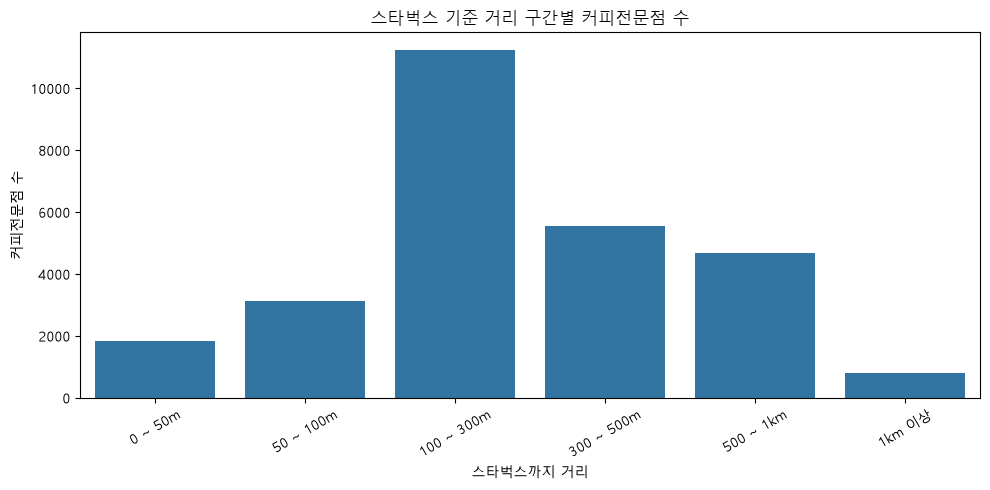

In [193]:
plt.figure(figsize=(10, 5))
sns.barplot(data=distance_summary, x='거리구간', y='카페수')
plt.title('스타벅스 기준 거리 구간별 커피전문점 수')
plt.xlabel('스타벅스까지 거리')
plt.ylabel('커피전문점 수')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'distance_bucket_count.png', dpi=150, bbox_inches='tight')
plt.show()

### 반경별 누적 분석
거리 구간별 개수도 중요하지만 결론을 내릴떄는 "스타벅스 반경 100m 안에 몇 %가 있는가?" 처럼 누적 비율이 더 직관적

In [194]:
radius_list = [50, 100, 300, 500, 1000]

radius_summary = []
for radius in radius_list:
    count = (df_cafe_dist['스타벅스까지거리_m'] <= radius).sum()
    ratio = count / len(df_cafe_dist) * 100
    radius_summary.append({
        '반경': f'{radius}m 이내',
        '반경_m': radius,
        '카페수': count,
        '비율(%)': ratio
    })

radius_summary = pd.DataFrame(radius_summary)

In [195]:
radius_summary

,반경,반경_m,카페수,비율(%)
0,50m 이내,50,1837,6.741284
1,100m 이내,100,4975,18.256881
2,300m 이내,300,16223,59.533945
3,500m 이내,500,21783,79.937615
4,1000m 이내,1000,26458,97.093578


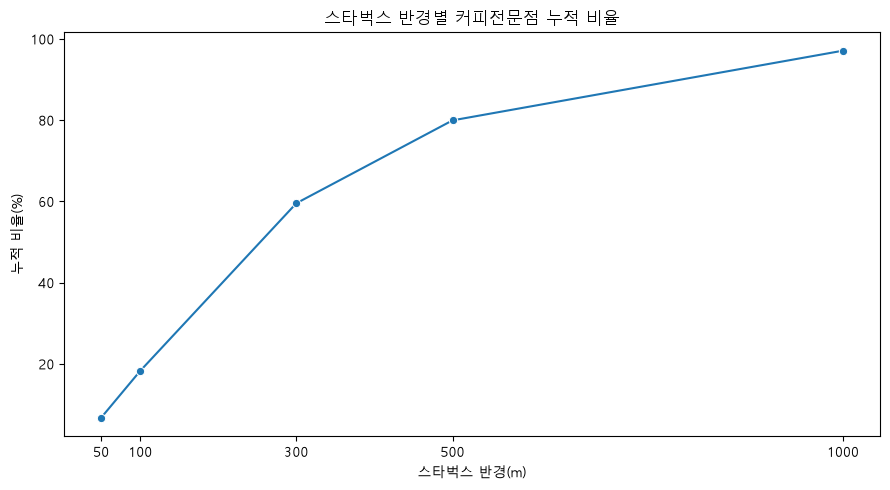

In [196]:
plt.figure(figsize=(9, 5))
sns.lineplot(data=radius_summary, x='반경_m', y='비율(%)', marker='o')
plt.title('스타벅스 반경별 커피전문점 누적 비율')
plt.xlabel('스타벅스 반경(m)')
plt.ylabel('누적 비율(%)')
plt.xticks(radius_list)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'radius_cumulative_ratio.png', dpi=150, bbox_inches='tight')
plt.show()

### 브랜드별 평균 거리 분석
브랜드별로 스타벅스와의 평균 거리, 중앙값 거리, 100m 이내 비율, 300m 이내 비율을 비교
- 평균 거리가 짧다: 스타벅스와 가까운 위치에 많이 분포할 가능성이 있음
- 중앙값도 함께 보기: 일부 극단값이 왜곡할 수 있기 때문에 확인이 필요
- 100m/300m 이내 비율: 실제로 가까운 매장이 얼마나 많은가를 보여주기 위해 확인


In [197]:
brand_distance = (df_cafe_dist.groupby('브랜드명').agg(
    매장수=('상호명', 'count'),
    평균거리_m=('스타벅스까지거리_m', 'mean'),
    중앙값거리_m=('스타벅스까지거리_m', 'median'),
    최소거리_m=('스타벅스까지거리_m', 'min'),
    최대거리_m=('스타벅스까지거리_m', 'max')
    ).reset_index()
)

In [198]:
brand_distance 

,브랜드명,매장수,평균거리_m,중앙값거리_m,최소거리_m,최대거리_m
0,기타커피전문점,23467,326.536861,248.849333,0.144726,3000.906804
1,더벤티,158,334.779032,227.555068,9.705427,2028.880755
2,매머드커피,450,240.991458,160.955413,6.116809,3000.906804
3,메가커피,979,351.769845,258.240538,0.448320,2053.356017
4,빽다방,372,292.241806,189.815816,6.681414,1509.265695
5,이디야,436,358.278872,256.821202,8.073784,2216.424374
6,커피빈,240,126.673504,99.576121,0.389325,921.605025
7,컴포즈커피,458,326.599940,225.542648,2.656097,1891.347634
8,탐앤탐스,65,273.454980,144.129502,34.285891,2036.355810
9,텐퍼센트커피,87,225.151577,152.993819,21.156853,1023.878691


In [199]:
near_100 = df_cafe_dist.assign(반경100m=df_cafe_dist['스타벅스까지거리_m']<100).groupby('브랜드명')['반경100m'].mean()*100
near_100


브랜드명
기타커피전문점    17.283845
더벤티        20.886076
매머드커피      26.888889
메가커피       18.079673
빽다방        24.731183
이디야        16.513761
커피빈        50.000000
컴포즈커피      21.179039
탐앤탐스       29.230769
텐퍼센트커피     22.988506
투썸플레이스     31.914894
파스쿠찌       21.276596
할리스        33.043478
Name: 반경100m, dtype: float64

In [200]:
near_300 = df_cafe_dist.assign(반경100m=df_cafe_dist['스타벅스까지거리_m']<300).groupby('브랜드명')['반경100m'].mean()*100
near_300

브랜드명
기타커피전문점    58.375591
더벤티        65.822785
매머드커피      75.333333
메가커피       55.771195
빽다방        69.086022
이디야        56.192661
커피빈        94.583333
컴포즈커피      61.135371
탐앤탐스       72.307692
텐퍼센트커피     78.160920
투썸플레이스     76.063830
파스쿠찌       70.212766
할리스        80.000000
Name: 반경100m, dtype: float64

In [201]:
brand_distance = brand_distance.merge(near_100.rename('100m이내비율(%)'), on='브랜드명')
brand_distance

,브랜드명,매장수,평균거리_m,중앙값거리_m,최소거리_m,최대거리_m,100m이내비율(%)
0,기타커피전문점,23467,326.536861,248.849333,0.144726,3000.906804,17.283845
1,더벤티,158,334.779032,227.555068,9.705427,2028.880755,20.886076
2,매머드커피,450,240.991458,160.955413,6.116809,3000.906804,26.888889
3,메가커피,979,351.769845,258.240538,0.448320,2053.356017,18.079673
4,빽다방,372,292.241806,189.815816,6.681414,1509.265695,24.731183
5,이디야,436,358.278872,256.821202,8.073784,2216.424374,16.513761
6,커피빈,240,126.673504,99.576121,0.389325,921.605025,50.000000
7,컴포즈커피,458,326.599940,225.542648,2.656097,1891.347634,21.179039
8,탐앤탐스,65,273.454980,144.129502,34.285891,2036.355810,29.230769
9,텐퍼센트커피,87,225.151577,152.993819,21.156853,1023.878691,22.988506


In [202]:
brand_distance = brand_distance.merge(near_300.rename('300m이내비율(%)'), on='브랜드명')
brand_distance

,브랜드명,매장수,평균거리_m,중앙값거리_m,최소거리_m,최대거리_m,100m이내비율(%),300m이내비율(%)
0,기타커피전문점,23467,326.536861,248.849333,0.144726,3000.906804,17.283845,58.375591
1,더벤티,158,334.779032,227.555068,9.705427,2028.880755,20.886076,65.822785
2,매머드커피,450,240.991458,160.955413,6.116809,3000.906804,26.888889,75.333333
3,메가커피,979,351.769845,258.240538,0.448320,2053.356017,18.079673,55.771195
4,빽다방,372,292.241806,189.815816,6.681414,1509.265695,24.731183,69.086022
5,이디야,436,358.278872,256.821202,8.073784,2216.424374,16.513761,56.192661
6,커피빈,240,126.673504,99.576121,0.389325,921.605025,50.000000,94.583333
7,컴포즈커피,458,326.599940,225.542648,2.656097,1891.347634,21.179039,61.135371
8,탐앤탐스,65,273.454980,144.129502,34.285891,2036.355810,29.230769,72.307692
9,텐퍼센트커피,87,225.151577,152.993819,21.156853,1023.878691,22.988506,78.160920


In [203]:
# 매장 수가 너무 적은 브랜드는 해석이 불안정하므로 별도 기준 설정
MIN_STORE_COUNT = 50
brand_distance_filtered = brand_distance[brand_distance['매장수'] >= MIN_STORE_COUNT].copy()
brand_distance_filtered = brand_distance_filtered.sort_values('평균거리_m')
brand_distance_filtered

,브랜드명,매장수,평균거리_m,중앙값거리_m,최소거리_m,최대거리_m,100m이내비율(%),300m이내비율(%)
6,커피빈,240,126.673504,99.576121,0.389325,921.605025,50.000000,94.583333
12,할리스,115,214.813444,133.005394,31.331041,1071.348225,33.043478,80.000000
9,텐퍼센트커피,87,225.151577,152.993819,21.156853,1023.878691,22.988506,78.160920
2,매머드커피,450,240.991458,160.955413,6.116809,3000.906804,26.888889,75.333333
10,투썸플레이스,376,246.127555,150.434173,3.845199,2048.093719,31.914894,76.063830
8,탐앤탐스,65,273.454980,144.129502,34.285891,2036.355810,29.230769,72.307692
4,빽다방,372,292.241806,189.815816,6.681414,1509.265695,24.731183,69.086022
0,기타커피전문점,23467,326.536861,248.849333,0.144726,3000.906804,17.283845,58.375591
7,컴포즈커피,458,326.599940,225.542648,2.656097,1891.347634,21.179039,61.135371
1,더벤티,158,334.779032,227.555068,9.705427,2028.880755,20.886076,65.822785


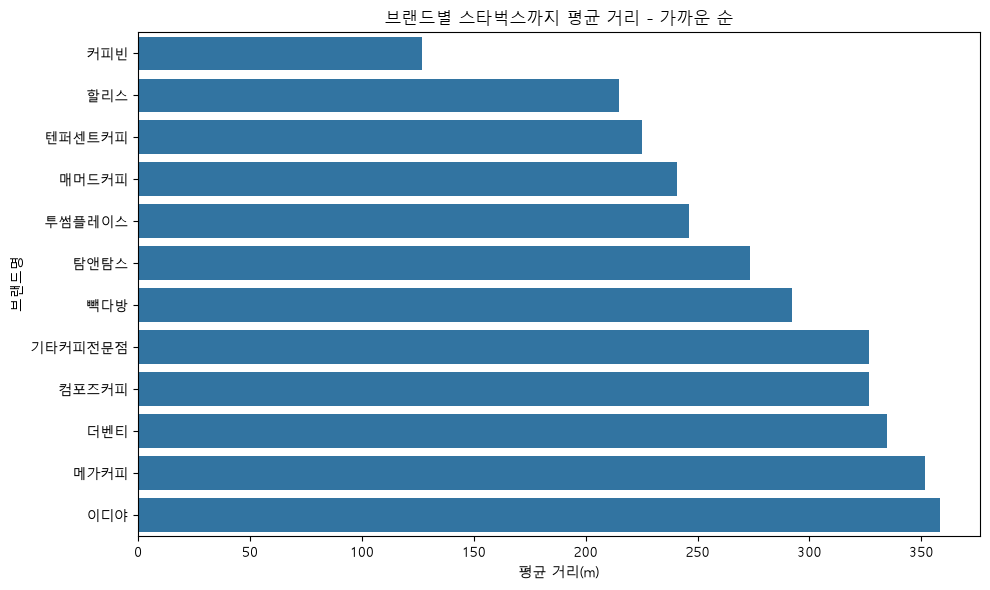

In [204]:
plt.figure(figsize=(10, 6))
plot_df = brand_distance_filtered.sort_values('평균거리_m').head(15)
sns.barplot(data=plot_df, y='브랜드명', x='평균거리_m')
plt.title('브랜드별 스타벅스까지 평균 거리 - 가까운 순')
plt.xlabel('평균 거리(m)')
plt.ylabel('브랜드명')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'brand_average_distance.png', dpi=150, bbox_inches='tight')
plt.show()

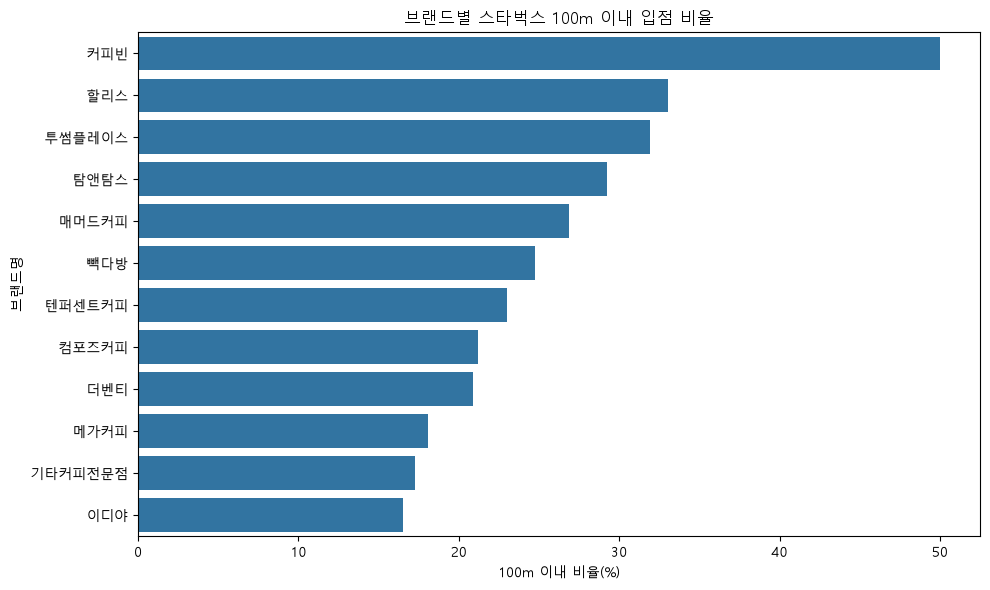

In [205]:
plt.figure(figsize=(10, 6))
plot_df = brand_distance_filtered.sort_values('100m이내비율(%)', ascending=False).head(15)
sns.barplot(data=plot_df, y='브랜드명', x='100m이내비율(%)')
plt.title('브랜드별 스타벅스 100m 이내 입점 비율')
plt.xlabel('100m 이내 비율(%)')
plt.ylabel('브랜드명')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'brand_near_100_ratio.png', dpi=150, bbox_inches='tight')
plt.show()

### 자치구별 분석
- 스타벅스와 커피전문점이 모두 특정 자치구에 몰려 있다면, 단순히 스타벅스 영향이라기보다 원래 상권이 강한 지역일 가능성이 있음
- 주소에서 서울 자치구를 추출하여 자치구별로 비교

In [206]:
def extract_gu(address):
    address = str(address)
    match = re.search(r'서울특별시\s+([가-힣]+구)|서울\s+([가-힣]+구)', address)  # 이거 전부 붙여서 써야 됨

    if match:
        return match.group(1) or match.group(2)

    match = re.search(r'([가-힣]+구)', address)

    if match:
        return match.group(1)

    return np.nan

In [207]:
df_cafe_dist['자치구'] = df_cafe_dist['도로명주소'].apply(extract_gu)
df_starbucks['자치구'] = df_starbucks['스타벅스주소'].apply(extract_gu)
cafe_gu = df_cafe_dist.groupby('자치구').size().reset_index(name='커피전문점수')
sb_gu = df_starbucks.groupby('자치구').size().reset_index(name='스타벅스수')

In [208]:
cafe_gu    

,자치구,커피전문점수
0,강남구,2742
1,강동구,975
2,강북구,571
3,강서구,1301
4,관악구,1066
5,광진구,962
6,구로구,781
7,금천구,679
8,노원구,880
9,도봉구,496


In [209]:
gu_summary = cafe_gu.merge(sb_gu, on='자치구', how='outer').fillna(0)
gu_summary['스타벅스1개당커피전문점수'] = gu_summary['커피전문점수']/gu_summary['스타벅스수'].replace(0, np.nan)
gu_summary = gu_summary.sort_values('스타벅스수', ascending=False)
gu_summary 

,자치구,커피전문점수,스타벅스수,스타벅스1개당커피전문점수
0,강남구,2742,104,26.365385
14,서초구,1583,59,26.830508
23,중구,1251,54,23.166667
19,영등포구,1379,47,29.340426
17,송파구,1635,42,38.928571
22,종로구,1392,41,33.951220
12,마포구,2014,38,53.000000
3,강서구,1301,34,38.264706
5,광진구,962,24,40.083333
13,서대문구,844,24,35.166667


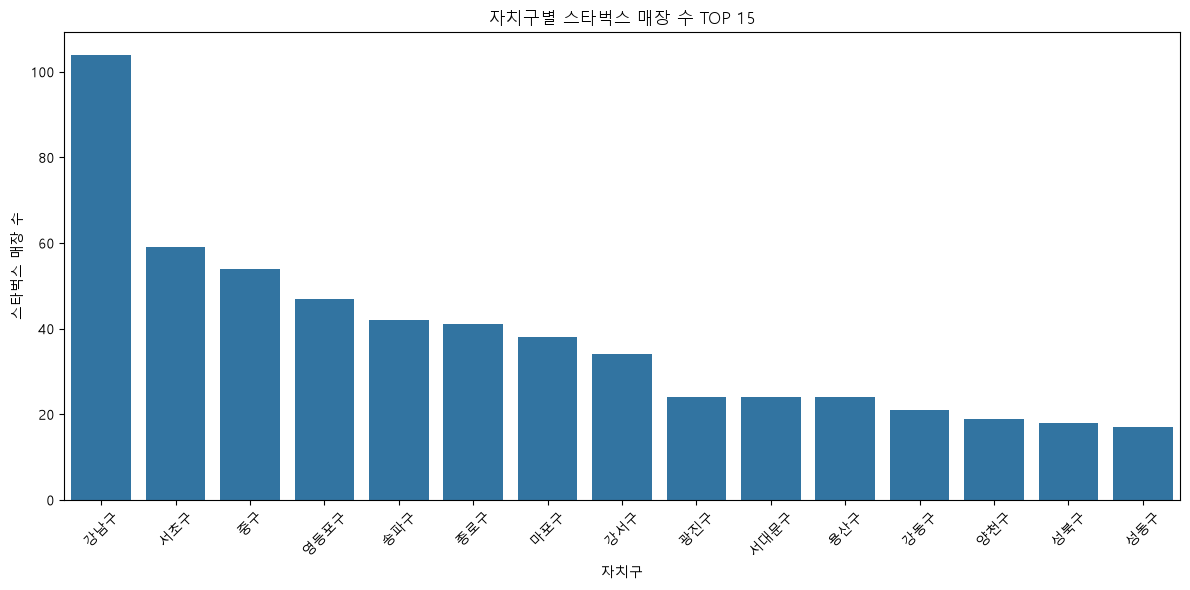

In [210]:
plt.figure(figsize=(12, 6))
plot_df = gu_summary.sort_values('스타벅스수', ascending=False).head(15)
sns.barplot(data=plot_df, x='자치구', y='스타벅스수')
plt.title('자치구별 스타벅스 매장 수 TOP 15')
plt.xlabel('자치구')
plt.ylabel('스타벅스 매장 수')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'gu_starbucks_count.png', dpi=150, bbox_inches='tight')
plt.show()

In [211]:
# 위에랑 같은 코드인듯

# plt.figure(figsize=(12, 6))
# plot_df = gu_summary.sort_values('커피전문점수', ascending=False).head(15)
# sns.barplot(data=plot_df, x='자치구', y='커피전문점수')
# plt.title('자치구별 커피전문점 수 TOP 15')
# plt.xlabel('자치구')
# plt.ylabel('커피전문점 수')
# plt.xticks(rotation=45)
# plt.tight_layout()
# plt.savefig(OUTPUT_DIR / 'gu_cafe_count.png', dpi=150, bbox_inches='tight')
# plt.show()

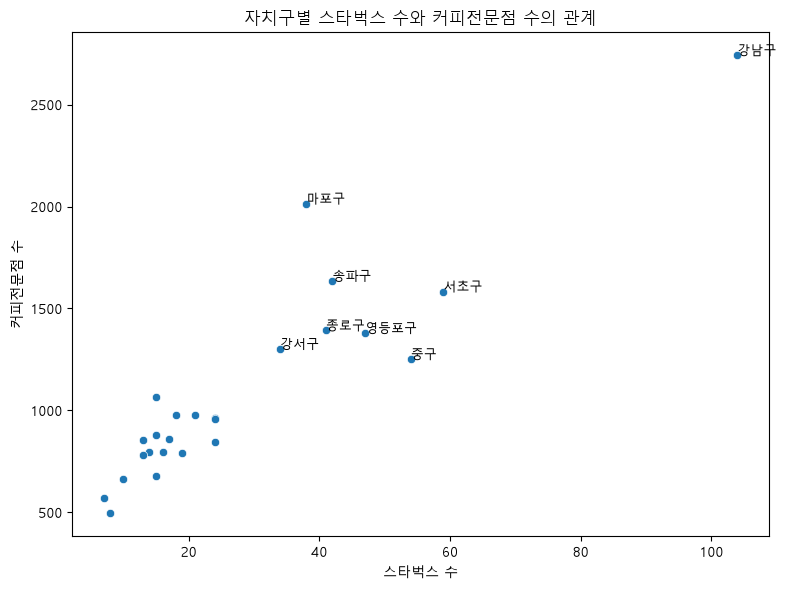

In [212]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=gu_summary, x='스타벅스수', y='커피전문점수')

for _, row in gu_summary.dropna(subset=['자치구']).iterrows():
    if row['스타벅스수'] >= gu_summary['스타벅스수'].quantile(0.7) or row['커피전문점수'] >= gu_summary['커피전문점수'].quantile(0.7):
        plt.text(row['스타벅스수'], row['커피전문점수'], row['자치구'], fontsize=9)

plt.title('자치구별 스타벅스 수와 커피전문점 수의 관계')
plt.xlabel('스타벅스 수')
plt.ylabel('커피전문점 수')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'gu_starbucks_vs_cafe_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

# **2. 지도 시각화**

### Folium
- 파이썬에서 대화형 지도를 생성할 수 있는 라이브러리
- 지리 데이터 시각화에 최적화 되어 있으며, 간단한 코드로 복잡한 지도 기능을 구현할 수 있도록 도와줌

In [213]:
import folium # pip install folium    

In [214]:
map_folium = folium.Map(location=[37.56652479270633, 126.9779129116262], zoom_start=15)

popup = folium.Popup('서울특별시청', max_width=200)
folium.Marker(location=[37.56652479270633, 126.9779129116262], popup=popup).add_to(map_folium)

popup = folium.Popup('덕수궁', max_width=200)
folium.Marker(location=[37.56585320879458, 126.97514572197248], popup=popup).add_to(map_folium)

popup = folium.Popup('서울지방경찰청', max_width=200)
folium.Marker(location=[37.57504045678939, 126.97195576938117], popup=popup).add_to(map_folium)

popup = folium.Popup('광화문', max_width=200)
folium.Marker(location=[37.57617987638928, 126.97694467807803], popup=popup).add_to(map_folium)

popup = folium.Popup('영풍문고-종로본점', max_width=200)
folium.Marker(location=[37.56999947440024, 126.98228391170936], popup=popup).add_to(map_folium)

map_folium

In [215]:
from folium.features import CustomIcon

In [216]:
icon = CustomIcon('spring2.png', icon_size=(45,45))


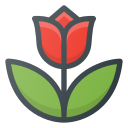

In [217]:
map_folium = folium.Map(location=[37.56652479270633, 126.9779129116262], zoom_start=15)

popup = folium.Popup('서울특별시청', max_width=200)
folium.Marker(location=[37.56652479270633, 126.9779129116262], popup=popup,
            icon=folium.Icon(icon='star', color='red')).add_to(map_folium)

popup = folium.Popup('덕수궁', max_width=200)
folium.Marker(location=[37.56585320879458, 126.97514572197248], popup=popup,
            icon=folium.Icon(icon='ok', color='pink')).add_to(map_folium)

popup = folium.Popup('서울지방경찰청', max_width=200)
folium.Marker(location=[37.57504045678939, 126.97195576938117], popup=popup,
            icon=icon).add_to(map_folium)

popup = folium.Popup('광화문', max_width=200)
folium.Marker(location=[37.57617987638928, 126.97694467807803], popup=popup).add_to(map_folium)

# CircleMarker(): 원의 범위를 마커로 설정
popup = folium.Popup('내땅', max_width=200)
folium.CircleMarker(location=[37.56999947440024, 126.98228391170936], popup=popup,
            radius=30, color='red', fill_color='#ec4074').add_to(map_folium)

map_folium

In [218]:
from folium.plugins import MarkerCluster     

In [222]:
MAX_CAFE_MARKERS = 3000

if len(df_cafe_dist) > MAX_CAFE_MARKERS:
    df_cafe_map = df_cafe_dist.sample(MAX_CAFE_MARKERS, random_state=2026).copy()
else:
    df_cafe_map = df_cafe_dist.copy()

m = folium.Map(location=[37.5665, 126.9780], zoom_start=11)

sb_cluster = MarkerCluster(name='스타벅스').add_to(m)
for _, row in df_starbucks.iterrows():
    folium.CircleMarker(location=[row['스타벅스위도'], row['스타벅스경도']],
                        radius=5, popup=f"스타벅스: {row['스타벅스지점명']}",
                        color='green', fill=True, fill_opacity=0.8).add_to(sb_cluster)


cafe_cluster = MarkerCluster(name='커피전문점').add_to(m)
for _, row in df_cafe_map.iterrows():
    folium.CircleMarker(location=[row['위도'], row['경도']],
                        radius=3, popup=f":{row['상호명']}/{row['브랜드명']}/{row['스타벅스까지거리_m']:.0f}m",
                        color='red', fill=True, fill_opacity=0.5).add_to(cafe_cluster)


folium.LayerControl().add_to(m)
m.save(OUTPUT_DIR/'starbucks_cafe_map.html')
print('지도 저장 완료')
m

지도 저장 완료


# **3. 분석 결과**

In [223]:
# 분석결과 저장
df_cafe_dist.to_csv(OUTPUT_DIR / 'cafe_with_nearest_starbucks.csv', index=False, encoding='utf-8-sig')
distance_summary.to_csv(OUTPUT_DIR / 'distance_summary.csv', index=False, encoding='utf-8-sig')
radius_summary.to_csv(OUTPUT_DIR / 'radius_summary.csv', index=False, encoding='utf-8-sig')
brand_distance_filtered.to_csv(OUTPUT_DIR / 'brand_distance_summary.csv', index=False, encoding='utf-8-sig')
gu_summary.to_csv(OUTPUT_DIR / 'gu_summary.csv', index=False, encoding='utf-8-sig')

print('CSV 저장 완료')
print('저장 위치:', OUTPUT_DIR)

CSV 저장 완료
저장 위치: c:\heeseung\02_DataAnalysis\output


In [224]:
# 최종 결론 작성용 요약 지표
total_cafe = len(df_cafe_dist)
near_100_count = (df_cafe_dist['스타벅스까지거리_m'] <= 100).sum()
near_300_count = (df_cafe_dist['스타벅스까지거리_m'] <= 300).sum()
near_500_count = (df_cafe_dist['스타벅스까지거리_m'] <= 500).sum()

near_100_ratio = near_100_count / total_cafe * 100
near_300_ratio = near_300_count / total_cafe * 100
near_500_ratio = near_500_count / total_cafe * 100

closest_brand = brand_distance_filtered.iloc[0]
most_near_100_brand = brand_distance_filtered.sort_values('100m이내비율(%)', ascending=False).iloc[0]

top_sb_gu = gu_summary.sort_values('스타벅스수', ascending=False).iloc[0]
top_cafe_gu = gu_summary.sort_values('커피전문점수', ascending=False).iloc[0]

print('===== 최종 분석 요약 =====')
print(f'전체 커피전문점 수: {total_cafe:,}개')
print(f'스타벅스 100m 이내 커피전문점: {near_100_count:,}개 ({near_100_ratio:.2f}%)')
print(f'스타벅스 300m 이내 커피전문점: {near_300_count:,}개 ({near_300_ratio:.2f}%)')
print(f'스타벅스 500m 이내 커피전문점: {near_500_count:,}개 ({near_500_ratio:.2f}%)')
print()
print(f'평균 거리 기준 스타벅스와 가장 가까운 브랜드: {closest_brand["브랜드명"]} / 평균 {closest_brand["평균거리_m"]:.1f}m')
print(f'100m 이내 비율이 가장 높은 브랜드: {most_near_100_brand["브랜드명"]} / {most_near_100_brand["100m이내비율(%)"]:.2f}%')
print()
print(f'스타벅스가 가장 많은 자치구: {top_sb_gu["자치구"]} / {top_sb_gu["스타벅스수"]}개')
print(f'커피전문점이 가장 많은 자치구: {top_cafe_gu["자치구"]} / {top_cafe_gu["커피전문점수"]}개')

===== 최종 분석 요약 =====
전체 커피전문점 수: 27,250개
스타벅스 100m 이내 커피전문점: 4,975개 (18.26%)
스타벅스 300m 이내 커피전문점: 16,223개 (59.53%)
스타벅스 500m 이내 커피전문점: 21,783개 (79.94%)

평균 거리 기준 스타벅스와 가장 가까운 브랜드: 커피빈 / 평균 126.7m
100m 이내 비율이 가장 높은 브랜드: 커피빈 / 50.00%

스타벅스가 가장 많은 자치구: 강남구 / 104개
커피전문점이 가장 많은 자치구: 강남구 / 2742개


### 결론 작성
- 본 분석에서는 서울 지역 스타벅스 매장 위치와 소상공인 커피전문점 데이터를 이용하여 스타벅스 주변 상권에 커피전문점이 얼마나 분포하는지 확인
- 분석 결과, 스타벅스 반경 100, 300, 500 이내에 위치한 거피전문점 수와 비율을 확인할 수 있었으며, 일부 브랜드는 스타벅스와 상대적으로 가까운 위치에 많이 분포하는 경향을 보였음
- 또한 자치구별 분석 결과, 스타벅스 매장 수가 많은 지역은 커피전문점 수도 많은 경향을 보였음. 이는 스타벅스가 다른 커피전문점 입점에 직접적인 영향을 주었다기보다는, 유동인구가 많고 상권이 발달한 지역에 스타벅스와 다른 커피 전문점이 함께 밀집했을 가능성도 있음을 의미함
- 다른 자치구를 본 분석의 결론은 "특정 커피 브랜드가 스타벅스 주변에 가까이 분포하는 경향이 있다" 정도로 해설할 수 있음
- 다만 개업일 데이터나 매출 데이터가 없기 때문에 "스타벅스를 따라 입점했다"는 인과관계까지는 단정할 수 없음